# 🔍 Step 2: Exploratory Data Analysis & Feature Engineering

This notebook handles:
1. **Correlation Analysis** — Finding highly correlated feature pairs (>0.80)
2. **Feature Selection** — Dropping redundant columns (RANK, fantasy, identifiers)
3. **VIF Analysis** — Removing multicollinearity
4. **Distribution Plots** — Visualizing each feature vs. salary

**Input:** Merged dataset from Step 1  
**Output:** Clean feature set (`df_filtred3`) ready for modeling

## 2.0 Load the Data from Step 1

> If you ran `01_data_collection.ipynb` in the same session, `df_inner` is already in memory.  
> Otherwise, run the cell below to reload from CSV files.

In [3]:
import pandas as pd
import numpy as np
import unicodedata

# Reload from CSVs if df_inner is not in memory
try:
    df_inner.shape
    print(f"df_inner already in memory: {df_inner.shape}")
except NameError:
    df_stats = pd.read_csv("../data/nba_stats_2025_26.csv")
    df_salaries = pd.read_csv("../data/nba_salaries_2026_27.csv")
    
    def clean_name_simple(name):
        if pd.isna(name):
            return name
        name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
        name = name.replace('.', '')
        return name.upper().strip()
    
    df_salaries["PLAYER_NAME"] = df_salaries["PLAYER_NAME"].apply(clean_name_simple)
    df_stats["PLAYER_NAME"] = df_stats["PLAYER_NAME"].apply(clean_name_simple)
    df_inner = pd.merge(df_stats, df_salaries, on="PLAYER_NAME", how="inner")
    print(f"df_inner reloaded from CSVs: {df_inner.shape}")

df_inner already in memory: (379, 68)


## 2.1 Initial Correlation Analysis (Raw Features)

In [4]:
import pandas as pd
import numpy as np

# ==========================================
# PART 1: FINDING HIGHLY CORRELATED PAIRS (> 0.80)
# ==========================================
print("Finding dangerous feature pairs with correlation greater than 0.80...\n")

# Extract only numeric columns for correlation
numeric_data = df_stats.select_dtypes(include=[np.number])

# We take the absolute value of the correlation matrix (inverse proportion ruins the model in the same way)
corr_matrix = numeric_data.corr().abs()

# We only take the upper triangle (To prevent a feature from being 100% correlated with itself)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# OPTIMIZATION: Instead of using slow 'for' loops, we use pandas' built-in unstack method
# This converts the matrix into a Series, drops NaNs, and filters values > 0.80
high_corr_series = upper_triangle.unstack().dropna()
high_corr_series = high_corr_series[high_corr_series > 0.80]

if not high_corr_series.empty:
    # Convert the Series back to a DataFrame
    df_high_corr = high_corr_series.reset_index()
    df_high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    # Sort by correlation value
    df_high_corr = df_high_corr.sort_values(by="Correlation", ascending=False).reset_index(drop=True)
    
    # ERROR FIXED PART: Formatted with Lambda
    colored_corr = df_high_corr.style.format({
        "Correlation": lambda x: f"{x:.3f} ( {x*100:.1f}% Same )"
    }).background_gradient(subset=['Correlation'], cmap='YlOrRd')
    
    display(colored_corr)
else:
    print("Super! No pairs with correlation above 0.80 were found.")

Finding dangerous feature pairs with correlation greater than 0.80...



,Feature 1,Feature 2,Correlation
0,MIN_RANK,MIN,0.999 ( 99.9% Same )
1,FP_HIGH_SCORE_RANK,NBA_FANTASY_PTS_RANK,0.997 ( 99.7% Same )
2,FP_HIGH_SCORE,NBA_FANTASY_PTS,0.996 ( 99.6% Same )
3,WNBA_FANTASY_PTS,NBA_FANTASY_PTS,0.994 ( 99.4% Same )
4,WNBA_FANTASY_PTS_RANK,NBA_FANTASY_PTS_RANK,0.994 ( 99.4% Same )
5,FP_HIGH_SCORE_RANK,WNBA_FANTASY_PTS_RANK,0.993 ( 99.3% Same )
6,FP_HIGH_SCORE,WNBA_FANTASY_PTS,0.993 ( 99.3% Same )
7,W_RANK,W,0.993 ( 99.3% Same )
8,PTS_RANK,FGM_RANK,0.993 ( 99.3% Same )
9,W_PCT_RANK,W_PCT,0.992 ( 99.2% Same )


## 2.2 Drop RANK Columns and Redundant Features

In [5]:
import pandas as pd
import numpy as np

# 1. Find and drop all features containing "RANK"
rank_columns = [col for col in df_inner.columns if 'RANK' in col.upper()]
df_norank = df_inner.drop(columns=rank_columns, errors='ignore')
print(f"\U0001f9f9 A total of {len(rank_columns)} 'RANK' columns were dropped.")

# 2. Drop ID, team names, and fantasy points
extras_to_drop = [
    'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 
    'NBA_FANTASY_PTS', 'WNBA_FANTASY_PTS', 'FP_HIGH_SCORE'
]
df_filtred1 = df_norank.drop(columns=extras_to_drop, errors='ignore')
print(f"\U0001f9f9 Names and fantasy points (6 columns) were dropped.")
print(f"\u2705 df_filtred1 successfully created! Remaining Column Count: {df_filtred1.shape[1]}\n")

# ==========================================
# 3. FINDING HIGHLY CORRELATED PAIRS (> 0.80)
# ==========================================
print("Searching for dangerous feature pairs with correlation greater than 0.80...\n")

# We only proceed with numerical data
numeric_data = df_filtred1.select_dtypes(include=[np.number])

# We take the absolute value of the correlation matrix
corr_matrix = numeric_data.corr().abs()

# We take the upper triangle to eliminate 100% correlation with itself
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_correlations = []
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        correlation_value = upper_triangle.loc[row, col]
        if correlation_value > 0.80:
            high_correlations.append({
                'Feature 1': row,
                'Feature 2': col,
                'Correlation': correlation_value
            })

df_high_corr = pd.DataFrame(high_correlations)

if not df_high_corr.empty:
    df_high_corr = df_high_corr.sort_values(by="Correlation", ascending=False).reset_index(drop=True)
    
    # Display in heatmap format
    colored_corr = df_high_corr.style.format({
        "Correlation": lambda x: f"{x:.3f} ( {x*100:.1f}% Same )"
    }).background_gradient(subset=['Correlation'], cmap='YlOrRd')
    
    display(colored_corr)
else:
    print("Super! No pairs with correlation above 0.80 were found.")

🧹 A total of 31 'RANK' columns were dropped.
🧹 Names and fantasy points (6 columns) were dropped.
✅ df_filtred1 successfully created! Remaining Column Count: 31

Searching for dangerous feature pairs with correlation greater than 0.80...



,Feature 1,Feature 2,Correlation
0,FGM,PTS,0.989 ( 98.9% Same )
1,FTM,FTA,0.989 ( 98.9% Same )
2,FG3M,FG3A,0.986 ( 98.6% Same )
3,FGA,PTS,0.982 ( 98.2% Same )
4,FGM,FGA,0.975 ( 97.5% Same )
5,FTA,PFD,0.974 ( 97.4% Same )
6,DREB,REB,0.961 ( 96.1% Same )
7,FTM,PFD,0.959 ( 95.9% Same )
8,FTM,PTS,0.908 ( 90.8% Same )
9,FTA,PTS,0.893 ( 89.3% Same )


## 2.3 Manual Feature Dropping (Correlated Pairs)

In [6]:
import pandas as pd
import numpy as np

# 1. Write the names of the columns you want to drop here (I wrote the most inflating ones as an example)
manual_drop_list = [
    'FGM', 'FGA',     # Shot attempts/makes are usually unnecessary when PTS (Points) is present
    'FTM', 'FTA',     # Free throws are unnecessary when PTS and PFD (Personal Fouls Drawn) are present
    'FG3A','FG3M',    # Unnecessary when FG3_PCT or PTS is present
    'DREB'            # Unnecessary when REB (Total Rebounds) is present
]

# 2. Drop the features you selected from df_filtred1 and save as df_filtred2
df_filtred2 = df_filtred1.drop(columns=manual_drop_list, errors='ignore')
print(f"\U0001f9f9 {len(manual_drop_list)} features were dropped manually.")
print(f"\u2705 df_filtred2 successfully created! Remaining Column Count: {df_filtred2.shape[1]}\n")

# ==========================================
# 3. CORRELATION CHECK FOR THE NEW DATAFRAME (> 0.80)
# ==========================================
print("Searching for pairs with correlation greater than 0.80 among remaining features...\n")

numeric_data2 = df_filtred2.select_dtypes(include=[np.number])
corr_matrix2 = numeric_data2.corr().abs()
upper_triangle2 = corr_matrix2.where(np.triu(np.ones(corr_matrix2.shape), k=1).astype(bool))

high_correlations2 = []
for col in upper_triangle2.columns:
    for row in upper_triangle2.index:
        correlation_value2 = upper_triangle2.loc[row, col]
        if correlation_value2 > 0.80:
            high_correlations2.append({
                'Feature 1': row,
                'Feature 2': col,
                'Correlation': correlation_value2
            })

df_high_corr2 = pd.DataFrame(high_correlations2)

if not df_high_corr2.empty:
    df_high_corr2 = df_high_corr2.sort_values(by="Correlation", ascending=False).reset_index(drop=True)
    
    colored_corr2 = df_high_corr2.style.format({
        "Correlation": lambda x: f"{x:.3f} ( {x*100:.1f}% Same )"
    }).background_gradient(subset=['Correlation'], cmap='YlOrRd')
    
    display(colored_corr2)
else:
    print("\U0001f389 Perfect! No pairs with correlation above 0.80 left in df_filtred2.")

🧹 7 features were dropped manually.
✅ df_filtred2 successfully created! Remaining Column Count: 24

Searching for pairs with correlation greater than 0.80 among remaining features...



,Feature 1,Feature 2,Correlation
0,PFD,PTS,0.891 ( 89.1% Same )
1,MIN,PTS,0.865 ( 86.5% Same )
2,AST,TOV,0.851 ( 85.1% Same )
3,TOV,PTS,0.839 ( 83.9% Same )
4,TOV,PFD,0.816 ( 81.6% Same )
5,OREB,REB,0.811 ( 81.1% Same )


## 2.4 VIF (Variance Inflation Factor) Analysis

In [7]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')

# Take only numeric data and drop SALARY
numeric_data_vif = df_filtred2.select_dtypes(include=[np.number])
X_vif = numeric_data_vif.drop(columns=['SALARY'], errors='ignore')

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_values = []
for i in range(len(X_vif.columns)):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
    except:
        vif_val = np.inf 
    vif_values.append(vif_val)

vif_data["VIF_Score"] = vif_values
vif_data['VIF_Score'] = vif_data['VIF_Score'].replace([np.inf, -np.inf], 999999)
vif_data = vif_data.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)

def color_vif(val):
    if val > 10:
        return 'color: white; background-color: darkred'
    elif val > 5:
        return 'color: black; background-color: orange'
    else:
        return 'color: black; background-color: lightgreen'

colored_vif = vif_data.style.map(color_vif, subset=['VIF_Score']).format({
    "VIF_Score": "{:.2f}"
})

display(colored_vif)

,Feature,VIF_Score
0,GP,1000799917193443.50
1,W,1000799917193443.50
2,L,1000799917193443.50
3,PTS,16.21
4,W_PCT,12.31
5,REB,11.51
6,MIN,10.78
7,TOV,9.70
8,PFD,7.75
9,OREB,6.81


## 2.5 Drop High-VIF Features → df_filtred3

In [8]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')

# 1. Write the columns that show up red (very high) in the VIF table and you want to drop here
vif_features_to_drop = [
    'W',  # Example: Minutes usually inflate everything
    'L'   # Example: PTS can be dropped if shooting stats are kept
]

# 2. Drop the features you selected from df_filtred2 and save as df_filtred3
df_filtred3 = df_filtred2.drop(columns=vif_features_to_drop, errors='ignore')
print(f"\U0001f9f9 {len(vif_features_to_drop)} features dropped. df_filtred3 remaining column count: {df_filtred3.shape[1]}\n")

# 3. VIF CALCULATION FOR THE NEW DATAFRAME (df_filtred3)
numeric_data_vif = df_filtred3.select_dtypes(include=[np.number])
X_vif = numeric_data_vif.drop(columns=['SALARY'], errors='ignore')

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_values = []
for i in range(len(X_vif.columns)):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
    except:
        vif_val = np.inf 
    vif_values.append(vif_val)

vif_data["VIF_Score"] = vif_values
vif_data['VIF_Score'] = vif_data['VIF_Score'].replace([np.inf, -np.inf], 999999)
vif_data = vif_data.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)

def color_vif(val):
    if val > 10:
        return 'color: white; background-color: darkred'
    elif val > 5:
        return 'color: black; background-color: orange'
    else:
        return 'color: black; background-color: lightgreen'

colored_vif = vif_data.style.map(color_vif, subset=['VIF_Score']).format({
    "VIF_Score": "{:.2f}"
})

display(colored_vif)

🧹 2 features dropped. df_filtred3 remaining column count: 22



,Feature,VIF_Score
0,PTS,16.21
1,REB,11.48
2,MIN,10.78
3,TOV,9.70
4,PFD,7.72
5,OREB,6.81
6,AST,6.23
7,DD2,4.60
8,PLUS_MINUS,3.51
9,BLKA,3.24


## 2.6 Distribution Plots (All Features vs. Salary)

Plotting graphs for a total of 21 different cleaned features...

✅ Graph successfully saved to your computer: ../outputs/plots/df_filtred3_distribution.png


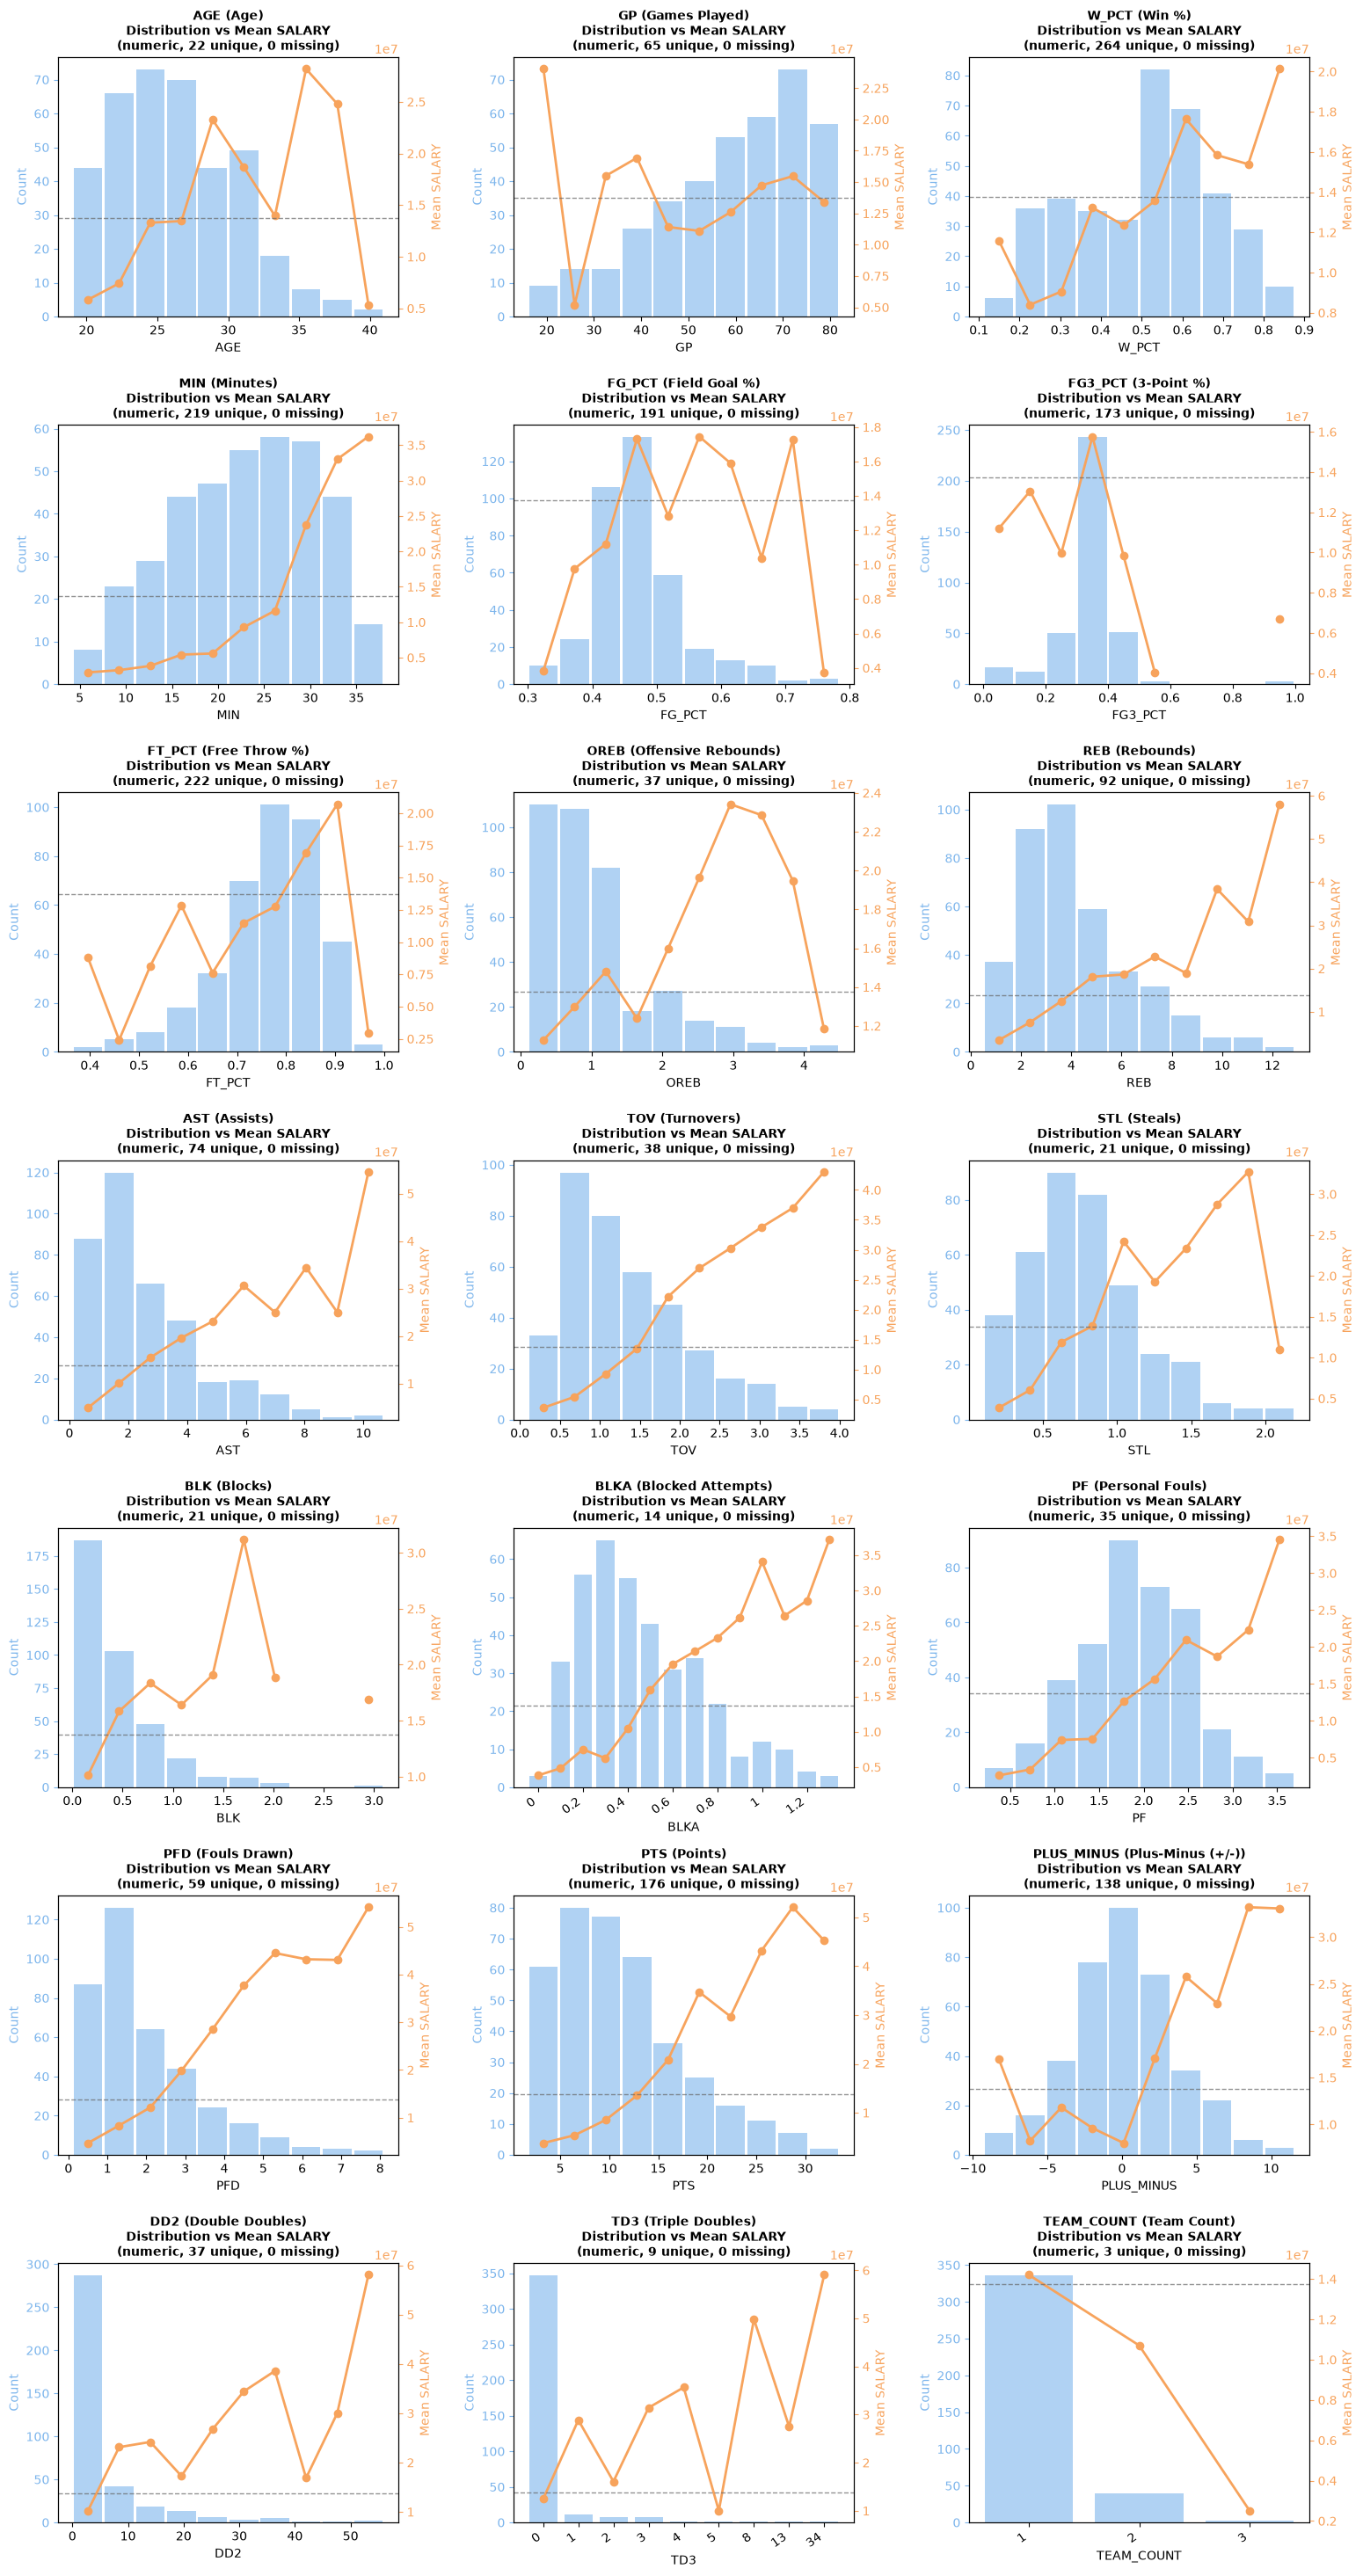

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Color Definitions
BAR_COLOR = "#7cb5ec"   
LINE_COLOR = "#f7a35c"  

# Full Forms of NBA Abbreviations
NBA_DICT = {
    'AGE': 'Age',
    'MIN': 'Minutes',
    'PTS': 'Points',
    'REB': 'Rebounds',
    'AST': 'Assists',
    'TOV': 'Turnovers',
    'STL': 'Steals',
    'BLK': 'Blocks',
    'PFD': 'Fouls Drawn',
    'PLUS_MINUS': 'Plus-Minus (+/-)',
    'FG_PCT': 'Field Goal %',
    'FG3_PCT': '3-Point %',
    'GP': 'Games Played',
    'TEAM_ABBREVIATION': 'Team',
    'W_PCT': 'Win %',
    'FG3M': '3-Pointers Made',
    'FT_PCT': 'Free Throw %',
    'OREB': 'Offensive Rebounds',
    'BLKA': 'Blocked Attempts',
    'PF': 'Personal Fouls',
    'DD2': 'Double Doubles',
    'TD3': 'Triple Doubles',
    'FG3_PCT_RANK': '3-Point % Rank',
    'DD2_RANK': 'Double Double Rank',
    'TD3_RANK': 'Triple Double Rank',
    'TEAM_COUNT': 'Team Count'
}

def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5.2, 4.2),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,
    save_path: str = None
):
    def is_categorical(s: pd.Series) -> bool:
        return (
            s.dtype == "object"
            or pd.api.types.is_string_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
        )

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))
    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        n_nan = int(df[col].isna().sum())
        n_unique = int(df[col].nunique(dropna=True))
        s = df[col]
        
        col_full_name = f"{col} ({NBA_DICT.get(col, col)})" if col in NBA_DICT else col

        if is_categorical(s):
            type_str = "categorical"
            tmp = df[[col, target_col]].copy()
            tmp[col] = tmp[col].astype("object").where(tmp[col].notna(), "(missing)")

            counts = tmp[col].value_counts()
            mean_y = tmp.groupby(col, dropna=False)[target_col].mean()

            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])
                ordered = [c for c in desired if c in counts.index]
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + sorted(remaining, key=str)
            else:
                final_order = sorted(counts.index, key=str)

            counts = counts.reindex(final_order)
            mean_y = mean_y.reindex(final_order)
            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.60, color=BAR_COLOR)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)
            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=35, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR, linewidth=2)
            ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
            ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                f"{col_full_name}\nDistribution vs Mean {target_col}\n"
                f"({type_str}, {n_unique} unique, {n_nan:,} missing)",
                fontsize=10, fontweight='bold'
            )

        else:
            type_str = "numeric"
            tmp = df[[col, target_col]].dropna()
            xvals = tmp[col].to_numpy()
            yvals = tmp[target_col].to_numpy()
            finite = np.isfinite(xvals) & np.isfinite(yvals)
            xvals, yvals = xvals[finite], yvals[finite]

            if len(xvals) == 0:
                ax1.set_title(f"{col} — empty after dropna")
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])
                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.60, color=BAR_COLOR)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)
                step = max(int(np.ceil(n_unique_eff / 10)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)
                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels([f"{v:g}" for v in unique_vals[tick_idx]], rotation=35, ha="right")

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR, linewidth=2)
                ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
                
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_idx = np.clip(np.digitize(xvals, bins, right=False) - 1, 0, n_bins - 1)
                counts = np.bincount(bin_idx, minlength=n_bins)
                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])
                centers = 0.5 * (bins[:-1] + bins[1:])
                width = (bins[1] - bins[0]) * 0.92

                ax1.bar(centers, counts, width=width, alpha=0.60, color=BAR_COLOR)
                
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(centers, mean_y, marker="o", color=LINE_COLOR, linewidth=2)
                ax2.axhline(df[target_col].mean(), color="0.4", linestyle="--", linewidth=1, alpha=0.7)
                
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_xlabel(col)
            ax1.set_title(
                f"{col_full_name}\nDistribution vs Mean {target_col}\n"
                f"({type_str}, {n_unique} unique, {n_nan:,} missing)",
                fontsize=10, fontweight='bold'
            )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"\n\u2705 Graph successfully saved to your computer: {save_path}")
        
    plt.show()

# ==============================================================================
# EXECUTION PART (Updated for df_filtred3)
# ==============================================================================

current_columns = [col for col in df_filtred3.columns if col != 'SALARY']

print(f"Plotting graphs for a total of {len(current_columns)} different cleaned features...")

plot_features_dual_axis(
    df=df_filtred3, 
    cols=current_columns, 
    target_col='SALARY', 
    n_bins=10,      
    n_wide=3,
    save_path="../outputs/plots/df_filtred3_distribution.png"  
)

---
**Next Step:** Open `03_modeling.ipynb` to train and evaluate ML models on the cleaned feature set.